## 1. Učitavanje biblioteka i podataka


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import MultinomialNB,ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold

import ssl
import re
import string
import nltk
from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score
from sklearn.metrics import roc_curve, auc

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /home/tamara/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/tamara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
data=pd.read_csv('../../Reviews.csv')
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
data["Score"].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

In [5]:
data_small, _ = train_test_split(
    data,
    train_size=100000,
    stratify=data["Score"],
    random_state=42
)
data_small["Score"].value_counts()

Score
5    63879
4    14188
1     9195
3     7501
2     5237
Name: count, dtype: int64

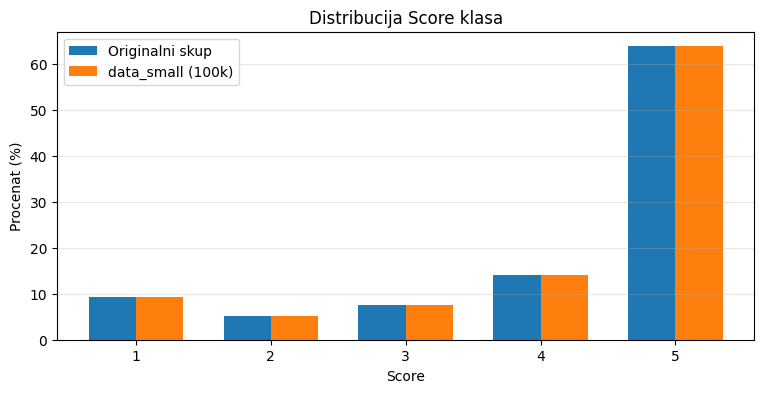

In [6]:
score_full = data["Score"].value_counts(normalize=True).sort_index() * 100
score_small = data_small["Score"].value_counts(normalize=True).sort_index() * 100

x = np.arange(len(score_full.index))
width = 0.35

plt.figure(figsize=(9,4))
plt.bar(x - width/2, score_full.values, width, label="Originalni skup")
plt.bar(x + width/2, score_small.values, width, label="data_small (100k)")

plt.xticks(x, score_full.index)
plt.title("Distribucija Score klasa")
plt.xlabel("Score")
plt.ylabel("Procenat (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


In [7]:
data_small.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               5
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   3
Text                      0
dtype: int64

In [11]:
data_sent = data_small[data_small['Score'] != 3].copy()

data_sent['Sentiment'] = data_sent['Score'].apply(lambda x: 'positive' if x > 3 else 'negative')
data_sent["Sentiment"] = data_sent["Sentiment"].apply(lambda x: 1 if x == 'positive' else 0)

In [12]:
data_small["TextFull"] = data_small["Summary"].fillna("") + " " + data_small["Text"].fillna("")
data_sent["TextFull"] = data_sent["Summary"].fillna("") + " " + data_sent["Text"].fillna("")

In [13]:
data_small.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,TextFull
301152,301153,B003Z6ZGZK,A3LN5V0RGOCTYY,Jim Brown,0,0,5,1347062400,Simplified,I can have a great cup of coffee whenever I fe...,Simplified I can have a great cup of coffee wh...
81192,81193,B0070PV73M,A2NVA94G5T50TA,Thomas F. Lonergan,0,0,5,1318636800,Excellent treat for training and walks,This is a favorite of Boxer and Rottie. It ha...,Excellent treat for training and walks This is...
122872,122873,B000FDMLV8,AZWR5854QIU2X,Mullough,0,0,5,1226275200,Delicious and easy,I enjoy the smell of fresh bread baking and us...,Delicious and easy I enjoy the smell of fresh ...
268999,269000,B004SRFYMK,A37XC5PH84JEO,"LucianaMachadoMKimonos ""LucianaMachadoSimon""",1,1,5,1340323200,As good as the other ones that I also gave 5 s...,"Zico is very good, but not better than the oth...",As good as the other ones that I also gave 5 s...
377424,377425,B001AML2LI,A9EHCOGPUJ0UH,M. Miller,4,4,5,1196899200,100 Calories Never Tasted So Good,Yummy! So great! If you enjoy mint and chocola...,100 Calories Never Tasted So Good Yummy! So gr...


In [14]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

data_small["cleaned_full"] = data_small["TextFull"].apply(clean_text)
data_small["cleaned_text"]=data_small["Text"].apply(clean_text)

data_sent["cleaned_full"] = data_sent["TextFull"].apply(clean_text)
data_sent["cleaned_text"] = data_sent["Text"].apply(clean_text)

In [15]:
final_data = data_small[["cleaned_text","cleaned_full","Score"]]
final_sent=data_sent[["cleaned_text","cleaned_full","Sentiment"]]

In [16]:
final_data.head()

,cleaned_text,cleaned_full,Score
301152,great cup coffee whenever feel like made easy ...,simplified great cup coffee whenever feel like...,5
81192,favorite boxer rottie pleasant aroma soft long...,excellent treat training walk favorite boxer r...,5
122872,enjoy smell fresh bread baking using mix bread...,delicious easy enjoy smell fresh bread baking ...,5
268999,zico good better one gave star tried brand zic...,good one also gave star zico good better one g...,5
377424,yummy great enjoy mint chocolate tasty mint co...,calorie never tasted good yummy great enjoy mi...,5


In [17]:
final_sent.head()

,cleaned_text,cleaned_full,Sentiment
301152,great cup coffee whenever feel like made easy ...,simplified great cup coffee whenever feel like...,1
81192,favorite boxer rottie pleasant aroma soft long...,excellent treat training walk favorite boxer r...,1
122872,enjoy smell fresh bread baking using mix bread...,delicious easy enjoy smell fresh bread baking ...,1
268999,zico good better one gave star tried brand zic...,good one also gave star zico good better one g...,1
377424,yummy great enjoy mint chocolate tasty mint co...,calorie never tasted good yummy great enjoy mi...,1


In [18]:
y = data_small["Score"]

X_text = data_small["cleaned_text"]
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

X_full = data_small["cleaned_full"]
X_full_train, X_full_test, y_train2, y_test2 = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

print((y_train.index == y_train2.index).all(), (y_test.index == y_test2.index).all())

True True


In [19]:
models = {
    "LinearSVC": LinearSVC(dual=True),
    "SGD hinge": SGDClassifier(loss="hinge", random_state=42),
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB(),
    "LogReg": LogisticRegression(max_iter=3000, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

tfidf_settings = {
    "TFIDF_10k": dict(max_features=10000, ngram_range=(1,2), min_df=2),
    "TFIDF_20k": dict(max_features=20000, ngram_range=(1,2), min_df=2),
}

def run_block(Xtr, Xte, ytr, yte, input_name):
    rows = []
    for tfidf_name, tfidf_kwargs in tfidf_settings.items():
        for model_name, model in models.items():

            print(f"Treniram: {input_name} | {tfidf_name} | {model_name} ...")

            pipe = Pipeline([
                ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
                ("clf", model)
            ])

            pipe.fit(Xtr, ytr)
            pred = pipe.predict(Xte)

            acc = accuracy_score(yte, pred)
            f1m = f1_score(yte, pred, average="macro")
            f1w = f1_score(yte, pred, average="weighted")

            print(f"  -> done | acc={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f}")

            rows.append({
                "Input": input_name,
                "TFIDF": tfidf_name,
                "Model": model_name,
                "Accuracy": acc,
                "F1_macro": f1m,
                "F1_weighted": f1w,
            })
    return rows

In [ ]:
rows = []
rows += run_block(X_text_train, X_text_test, y_train, y_test, "Text")
rows += run_block(X_full_train, X_full_test, y_train, y_test, "Summary+Text")

results_df = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df.head(20)

In [21]:
results_df

,Input,TFIDF,Model,Accuracy,F1_macro,F1_weighted
18,Summary+Text,TFIDF_20k,LinearSVC,0.75465,0.555676,0.734042
12,Summary+Text,TFIDF_10k,LinearSVC,0.75065,0.534843,0.725646
22,Summary+Text,TFIDF_20k,LogReg,0.75230,0.525474,0.719756
6,Text,TFIDF_20k,LinearSVC,0.73920,0.525446,0.715148
16,Summary+Text,TFIDF_10k,LogReg,0.74845,0.517581,0.716191
17,Summary+Text,TFIDF_10k,RandomForest,0.74250,0.499333,0.689411
0,Text,TFIDF_10k,LinearSVC,0.73010,0.498774,0.700881
23,Summary+Text,TFIDF_20k,RandomForest,0.73840,0.490526,0.682949
10,Text,TFIDF_20k,LogReg,0.73525,0.487505,0.696307
4,Text,TFIDF_10k,LogReg,0.73015,0.477855,0.691014


In [22]:
min_count = data_small["Score"].value_counts().min()

data_bal = (
    data_small.groupby("Score", group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(data_bal["Score"].value_counts())

Score
1    5237
2    5237
5    5237
3    5237
4    5237
Name: count, dtype: int64


In [23]:
X_text = data_bal["cleaned_text"]
X_full = data_bal["cleaned_full"]
y = data_bal["Score"]

Xtr_text, Xte_text, ytr, yte = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

Xtr_full, Xte_full, _, _ = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
rows = []
rows += run_block(Xtr_text, Xte_text, ytr, yte, "Text")
rows += run_block(Xtr_full, Xte_full, ytr, yte, "Summary+Text")

results_df_bal = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df_bal.head(20)

Treniram: Text | TFIDF_10k | LinearSVC ...
  -> done | acc=0.5041 | f1_macro=0.5020 | f1_weighted=0.5020
Treniram: Text | TFIDF_10k | SGD hinge ...
  -> done | acc=0.5148 | f1_macro=0.4978 | f1_weighted=0.4978
Treniram: Text | TFIDF_10k | MultinomialNB ...
  -> done | acc=0.5001 | f1_macro=0.4972 | f1_weighted=0.4972
Treniram: Text | TFIDF_10k | ComplementNB ...
  -> done | acc=0.4925 | f1_macro=0.4786 | f1_weighted=0.4786
Treniram: Text | TFIDF_10k | LogReg ...
  -> done | acc=0.5205 | f1_macro=0.5178 | f1_weighted=0.5178
Treniram: Text | TFIDF_10k | RandomForest ...
  -> done | acc=0.5192 | f1_macro=0.5113 | f1_weighted=0.5113
Treniram: Text | TFIDF_20k | LinearSVC ...
  -> done | acc=0.5230 | f1_macro=0.5212 | f1_weighted=0.5212
Treniram: Text | TFIDF_20k | SGD hinge ...
  -> done | acc=0.5205 | f1_macro=0.5049 | f1_weighted=0.5049
Treniram: Text | TFIDF_20k | MultinomialNB ...
  -> done | acc=0.5100 | f1_macro=0.5079 | f1_weighted=0.5079
Treniram: Text | TFIDF_20k | ComplementNB ..

,Input,TFIDF,Model,Accuracy,F1_macro,F1_weighted
22,Summary+Text,TFIDF_20k,LogReg,0.559099,0.556545,0.556554
16,Summary+Text,TFIDF_10k,LogReg,0.548215,0.545655,0.545665
23,Summary+Text,TFIDF_20k,RandomForest,0.554516,0.545589,0.545596
18,Summary+Text,TFIDF_20k,LinearSVC,0.546496,0.545228,0.545231
20,Summary+Text,TFIDF_20k,MultinomialNB,0.544205,0.541138,0.541144
12,Summary+Text,TFIDF_10k,LinearSVC,0.538476,0.536340,0.536347
17,Summary+Text,TFIDF_10k,RandomForest,0.543632,0.534543,0.534551
19,Summary+Text,TFIDF_20k,SGD hinge,0.549169,0.533771,0.533778
14,Summary+Text,TFIDF_10k,MultinomialNB,0.534466,0.530657,0.530662
10,Text,TFIDF_20k,LogReg,0.530074,0.527189,0.527198


In [ ]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def add_key(df):
    model_col = pick_col(df, ["Model", "model", "Classifier", "clf", "Alg", "Algorithm"])
    tfidf_col  = pick_col(df, ["TFIDF", "tfidf", "Vectorizer", "Features", "Representation"])
    block_col  = pick_col(df, ["Block", "Input", "Data", "TextType", "Variant"])

    metric_like = {"Accuracy","F1_macro","Precision_macro","Recall_macro","F1","Precision","Recall"}
    cols_for_key = [c for c in [block_col, tfidf_col, model_col] if c is not None]

    if len(cols_for_key) == 0:
        cols_for_key = [c for c in df.columns if c not in metric_like]

    df = df.copy()
    df["key"] = df[cols_for_key].astype(str).agg(" | ".join, axis=1)
    return df

u = add_key(results_df)
b = add_key(results_df_bal)


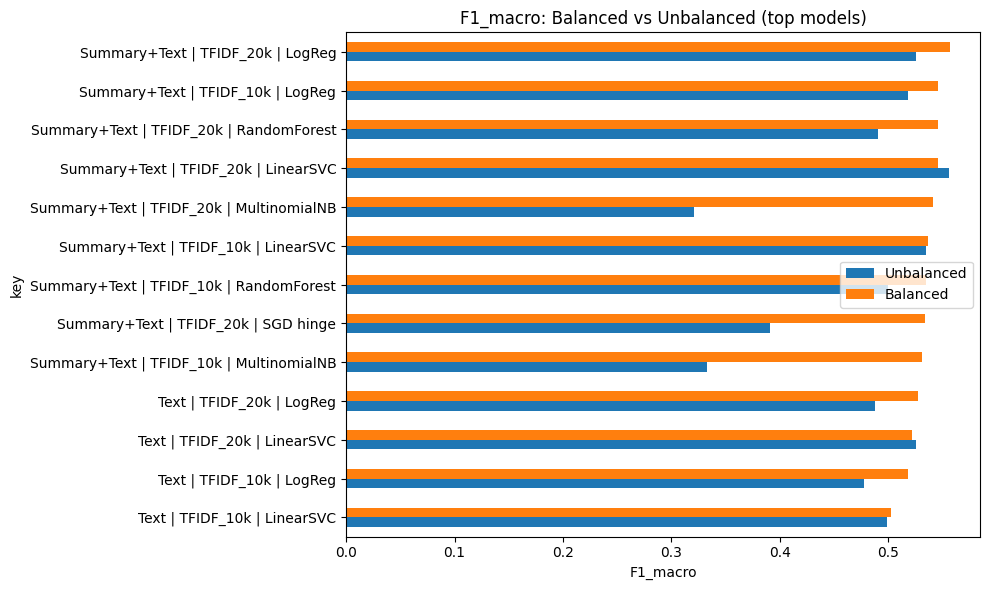

In [30]:
score_col = "F1_macro" 

N = 10
top_keys = pd.Index(u.sort_values(score_col, ascending=False).head(N)["key"]) \
            .union(b.sort_values(score_col, ascending=False).head(N)["key"])

plot_df = pd.DataFrame({
    "Unbalanced": u.set_index("key").reindex(top_keys)[score_col],
    "Balanced": b.set_index("key").reindex(top_keys)[score_col],
}).fillna(0)

ax = plot_df.sort_values("Balanced").plot(kind="barh", figsize=(10, 6))
ax.set_title(f"{score_col}: Balanced vs Unbalanced (top models)")
ax.set_xlabel(score_col)
plt.tight_layout()
plt.show()


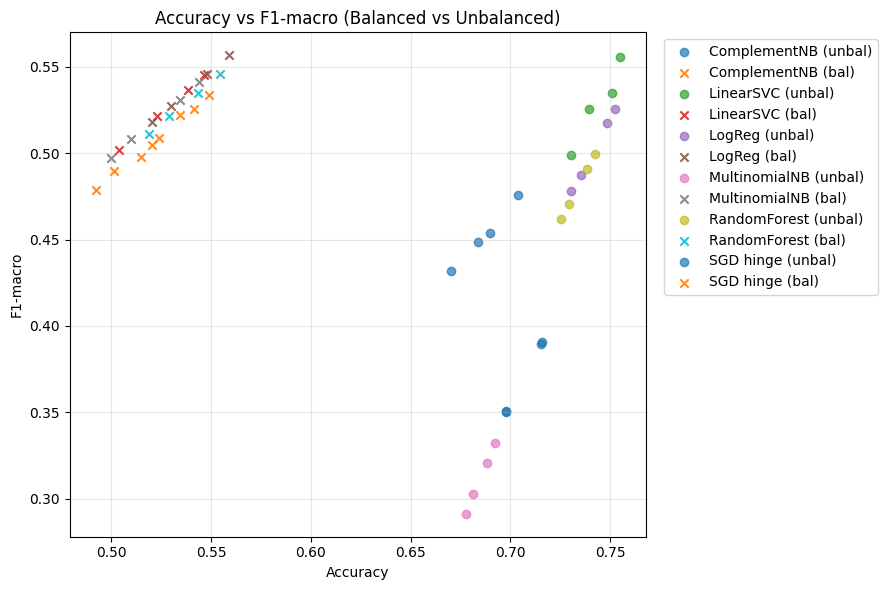

In [33]:
def scatter_by_model(u_df, b_df, title="Accuracy vs F1-macro"):
    plt.figure(figsize=(9,6))

    models = sorted(set(u_df["Model"].unique()) | set(b_df["Model"].unique()))

    for m in models:
        u = u_df[u_df["Model"] == m]
        b = b_df[b_df["Model"] == m]

        # Unbalanced (krug)
        if len(u) > 0:
            plt.scatter(u["Accuracy"], u["F1_macro"], marker="o", alpha=0.7, label=f"{m} (unbal)")

        # Balanced (X)
        if len(b) > 0:
            plt.scatter(b["Accuracy"], b["F1_macro"], marker="x", alpha=0.9, label=f"{m} (bal)")

    plt.title(title)
    plt.xlabel("Accuracy")
    plt.ylabel("F1-macro")
    plt.grid(True, alpha=0.3)

    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

scatter_by_model(results_df, results_df_bal, "Accuracy vs F1-macro (Balanced vs Unbalanced)")


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=3
)

grid.fit(X_text, y)
print(grid.best_params_)
print(grid.best_score_)

In [23]:
y = final_sent["Sentiment"]

X_text = final_sent["cleaned_text"]
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

X_full = final_sent["cleaned_full"]
X_full_train, X_full_test, y_train2, y_test2 = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

print((y_train.index == y_train2.index).all(), (y_test.index == y_test2.index).all())


True True


In [39]:
rows = []
rows += run_block(X_text_train, X_text_test, y_train, y_test, "Text")
rows += run_block(X_full_train, X_full_test, y_train, y_test, "Summary+Text")

results_df_sent = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df_sent.head(20)

Treniram: Text | TFIDF_10k | LinearSVC ...
  -> done | acc=0.9344 | f1_macro=0.8681 | f1_weighted=0.9324
Treniram: Text | TFIDF_10k | SGD hinge ...
  -> done | acc=0.9131 | f1_macro=0.7935 | f1_weighted=0.9016
Treniram: Text | TFIDF_10k | MultinomialNB ...
  -> done | acc=0.8950 | f1_macro=0.7288 | f1_weighted=0.8749
Treniram: Text | TFIDF_10k | ComplementNB ...
  -> done | acc=0.8800 | f1_macro=0.8095 | f1_weighted=0.8892
Treniram: Text | TFIDF_10k | LogReg ...
  -> done | acc=0.9260 | f1_macro=0.8392 | f1_weighted=0.9205
Treniram: Text | TFIDF_10k | RandomForest ...
  -> done | acc=0.9107 | f1_macro=0.7803 | f1_weighted=0.8968
Treniram: Text | TFIDF_20k | LinearSVC ...
  -> done | acc=0.9390 | f1_macro=0.8777 | f1_weighted=0.9373
Treniram: Text | TFIDF_20k | SGD hinge ...
  -> done | acc=0.9117 | f1_macro=0.7871 | f1_weighted=0.8991
Treniram: Text | TFIDF_20k | MultinomialNB ...
  -> done | acc=0.8932 | f1_macro=0.7212 | f1_weighted=0.8719
Treniram: Text | TFIDF_20k | ComplementNB ..

,Input,TFIDF,Model,Accuracy,F1_macro,F1_weighted
18,Summary+Text,TFIDF_20k,LinearSVC,0.950054,0.901215,0.949003
12,Summary+Text,TFIDF_10k,LinearSVC,0.947243,0.895055,0.945971
6,Text,TFIDF_20k,LinearSVC,0.939027,0.877745,0.937296
16,Summary+Text,TFIDF_10k,LogReg,0.939514,0.871846,0.935914
22,Summary+Text,TFIDF_20k,LogReg,0.939189,0.869944,0.935234
0,Text,TFIDF_10k,LinearSVC,0.934378,0.868059,0.932417
21,Summary+Text,TFIDF_20k,ComplementNB,0.912486,0.853128,0.917367
10,Text,TFIDF_20k,LogReg,0.927459,0.841001,0.921667
13,Summary+Text,TFIDF_10k,SGD hinge,0.929405,0.840615,0.922461
4,Text,TFIDF_10k,LogReg,0.926000,0.839177,0.920475


In [40]:
min_count = data_sent["Sentiment"].value_counts().min()

data_bal_sent = (
    data_sent.groupby("Sentiment", group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(data_bal_sent["Sentiment"].value_counts())

Sentiment
0    14432
1    14432
Name: count, dtype: int64


In [41]:
final_sent["Sentiment"].value_counts()

Sentiment
1    78067
0    14432
Name: count, dtype: int64

In [42]:
X_text = data_bal_sent["cleaned_text"]
X_full = data_bal_sent["cleaned_full"]
y = data_bal_sent["Sentiment"]

Xtr_text, Xte_text, ytr, yte = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

Xtr_full, Xte_full, _, _ = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)


In [43]:
rows = []
rows += run_block(Xtr_text, Xte_text, ytr, yte, "Text")
rows += run_block(Xtr_full, Xte_full, ytr, yte, "Summary+Text")

results_df_sent_bal = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df_sent_bal.head(20)

Treniram: Text | TFIDF_10k | LinearSVC ...
  -> done | acc=0.8813 | f1_macro=0.8813 | f1_weighted=0.8813
Treniram: Text | TFIDF_10k | SGD hinge ...
  -> done | acc=0.8824 | f1_macro=0.8824 | f1_weighted=0.8824
Treniram: Text | TFIDF_10k | MultinomialNB ...
  -> done | acc=0.8678 | f1_macro=0.8678 | f1_weighted=0.8678
Treniram: Text | TFIDF_10k | ComplementNB ...
  -> done | acc=0.8678 | f1_macro=0.8678 | f1_weighted=0.8678
Treniram: Text | TFIDF_10k | LogReg ...
  -> done | acc=0.8813 | f1_macro=0.8813 | f1_weighted=0.8813
Treniram: Text | TFIDF_10k | RandomForest ...
  -> done | acc=0.8678 | f1_macro=0.8678 | f1_weighted=0.8678
Treniram: Text | TFIDF_20k | LinearSVC ...
  -> done | acc=0.8827 | f1_macro=0.8827 | f1_weighted=0.8827
Treniram: Text | TFIDF_20k | SGD hinge ...
  -> done | acc=0.8848 | f1_macro=0.8848 | f1_weighted=0.8848
Treniram: Text | TFIDF_20k | MultinomialNB ...
  -> done | acc=0.8751 | f1_macro=0.8751 | f1_weighted=0.8751
Treniram: Text | TFIDF_20k | ComplementNB ..

,Input,TFIDF,Model,Accuracy,F1_macro,F1_weighted
18,Summary+Text,TFIDF_20k,LinearSVC,0.908886,0.908886,0.908886
19,Summary+Text,TFIDF_20k,SGD hinge,0.908367,0.908365,0.908365
22,Summary+Text,TFIDF_20k,LogReg,0.904556,0.904555,0.904555
13,Summary+Text,TFIDF_10k,SGD hinge,0.904382,0.904379,0.904379
16,Summary+Text,TFIDF_10k,LogReg,0.902477,0.902475,0.902475
12,Summary+Text,TFIDF_10k,LinearSVC,0.902304,0.902303,0.902303
23,Summary+Text,TFIDF_20k,RandomForest,0.892257,0.892257,0.892257
17,Summary+Text,TFIDF_10k,RandomForest,0.891564,0.891564,0.891564
21,Summary+Text,TFIDF_20k,ComplementNB,0.891391,0.891366,0.891365
20,Summary+Text,TFIDF_20k,MultinomialNB,0.891391,0.891366,0.891365


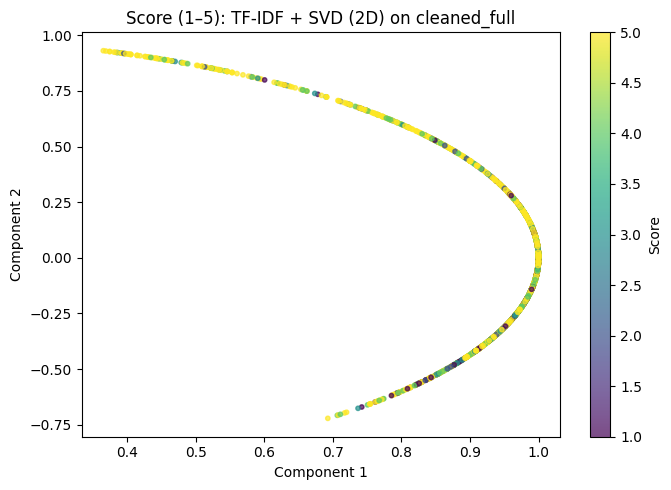

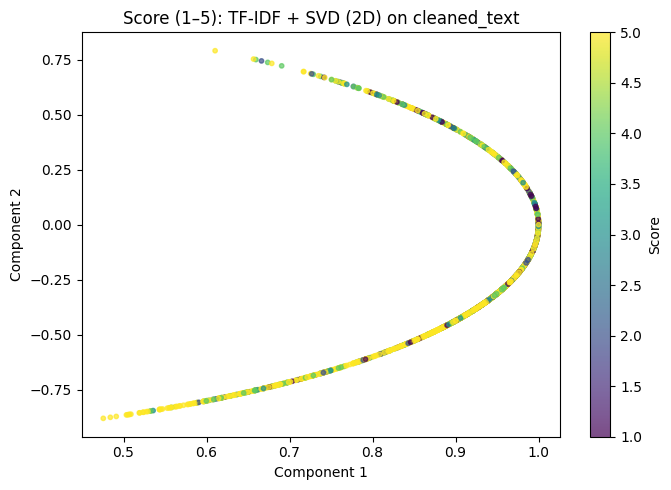

In [23]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
def plot_text_2d_svd(
    df, text_col, label_col,
    sample_n=2000, random_state=42,
    tfidf_max_features=20000,
    title="TF-IDF + TruncatedSVD (2D)"
):
    df2 = df[[text_col, label_col]].dropna()
    if len(df2) > sample_n:
        df2 = df2.sample(sample_n, random_state=random_state)

    X_text = df2[text_col].astype(str).values
    y = df2[label_col].values

    tfidf = TfidfVectorizer(
        max_features=tfidf_max_features,
        ngram_range=(1,2),
        min_df=2
    )
    X = tfidf.fit_transform(X_text)

    # LSA: sparse -> 2D
    svd = TruncatedSVD(n_components=2, random_state=random_state)
    lsa = make_pipeline(svd, Normalizer(copy=False))
    X_2d = lsa.fit_transform(X)

    plt.figure(figsize=(7,5))
    scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=y, s=10, alpha=0.7)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.colorbar(scatter, label=label_col)
    plt.tight_layout()
    plt.show()

# SCORE: cleaned_full (Summary+Text)
plot_text_2d_svd(
    df=data_small,
    text_col="cleaned_full",
    label_col="Score",
    sample_n=2000,
    title="Score (1–5): TF-IDF + SVD (2D) on cleaned_full"
)

# SCORE: cleaned_text (samo text)
plot_text_2d_svd(
    df=data_small,
    text_col="cleaned_text",
    label_col="Score",
    sample_n=2000,
    title="Score (1–5): TF-IDF + SVD (2D) on cleaned_text"
)
